In [1]:
import numpy as np
import matplotlib.pyplot as plt
from quantum_measurement.jw_expansion.l_qubit_correlation_simulator import LQubitCorrelationSimulator


In [2]:
try:
    from quantum_measurement.rust_simulator import FastLQubitSimulator as LQubitCorrelationSimulator
    print("Using Rust-accelerated simulator")
except ImportError:
    from quantum_measurement.jw_expansion.l_qubit_correlation_simulator import LQubitCorrelationSimulator
    print("Using Python simulator (Rust extension not available)")


Using Rust-accelerated simulator


# Single Trajectory Sainty:

In [3]:
# Set random seed for reproducibility
rng = np.random.default_rng(seed=42)

In [4]:
sim = LQubitCorrelationSimulator(
    L= 3,
    J=1.0,
    epsilon=0.1,
    N_steps=10000,
    T=8.0,
    closed_boundary=True
)

print(f"Simulation parameters:")
print(f"  J = {sim.J}")
print(f"  ε = {sim.epsilon}")
print(f"  N = {sim.N_steps}")
print(f"  T = {sim.T}")
print(f"  dt = {sim.dt:.6f}")
print(f"  T/τ = N×ε² = {sim.N_steps * sim.epsilon**2:.3f}")
print(f"  Theoretical ⟨Q⟩ = 3T/τ = {3 * sim.N_steps * sim.epsilon**2:.3f} (if A=0.5)")

Simulation parameters:
  J = 1.0
  ε = 0.1
  N = 10000
  T = 8.0
  dt = 0.000800
  T/τ = N×ε² = 100.000
  Theoretical ⟨Q⟩ = 3T/τ = 300.000 (if A=0.5)


In [5]:
# Simulate single trajectory
Q_traj, z_traj, xi_traj = sim.simulate_trajectory()
times = np.linspace(0, sim.T, sim.N_steps + 1)

ValueError: x and y must have same first dimension, but have shapes (10000,) and (1,)

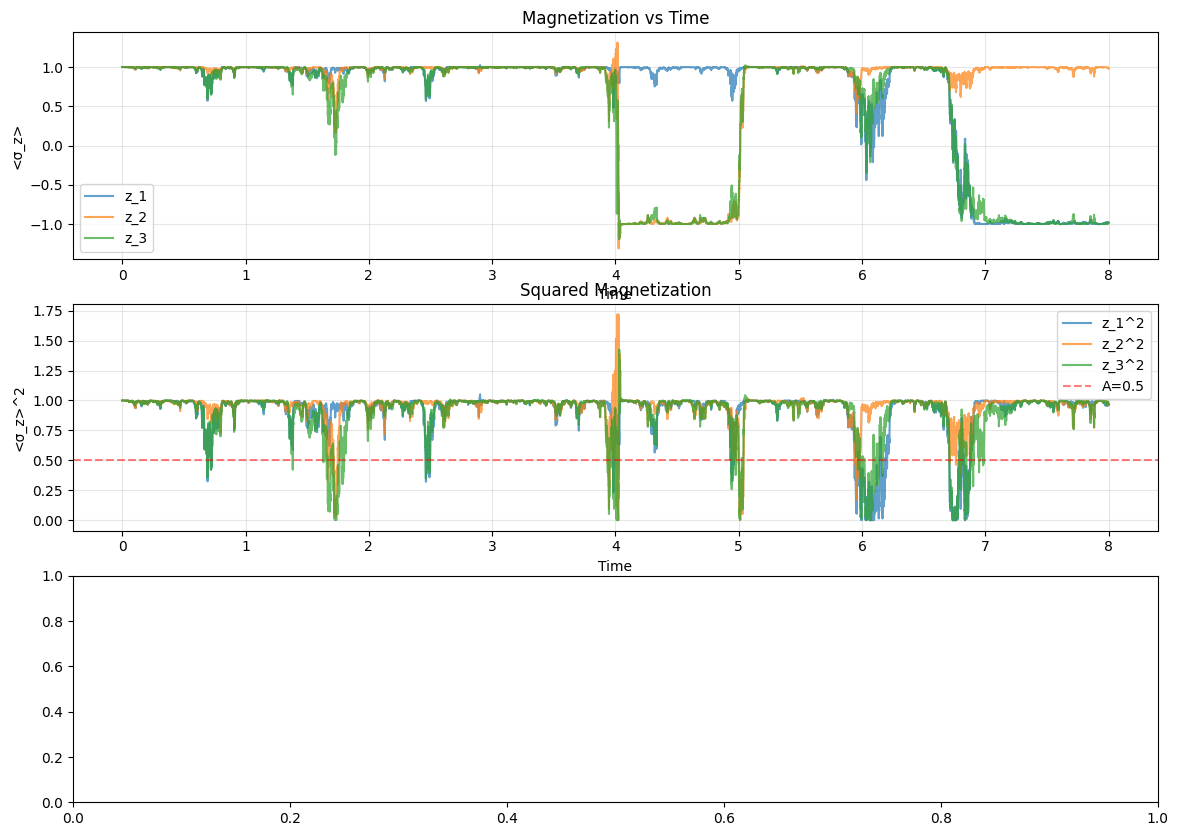

In [7]:
# Plot z values over time
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Plot z_i
for i in range(3):
    axes[0].plot(times, z_traj[:, i], label=f'z_{i+1}', alpha=0.7)
axes[0].set_xlabel('Time')
axes[0].set_ylabel('<σ_z>')
axes[0].set_title('Magnetization vs Time')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot z_i²
for i in range(3):
    axes[1].plot(times, z_traj[:, i]**2, label=f'z_{i+1}^2', alpha=0.7)
axes[1].axhline(y=0.5, color='r', linestyle='--', label='A=0.5', alpha=0.5)
axes[1].set_xlabel('Time')
axes[1].set_ylabel('<σ_z>^2')
axes[1].set_title('Squared Magnetization')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot z_i²
gamma = sim.epsilon**2/sim.dt
axes[2].plot(times[1:], Q_traj, label="Q")
axes[2].plot(times, times*2*gamma*sim.L, label="slope 2")
axes[2].plot(times, times*1.25*gamma*sim.L, label="slope 1.25")
axes[2].plot(times, times*(1 + np.average(z_traj**2))*gamma*sim.L, label="$1+\\langle z^2 \\rangle$")
axes[2].axhline(y=0.5, color='r', linestyle='--', label='A=0.5', alpha=0.5)
axes[2].set_xlabel('Time')
axes[2].set_ylabel('Q')
axes[2].set_title('EP')
axes[2].legend()
axes[2].grid(True, alpha=0.3)


plt.tight_layout()
plt.show()

# Trajectory for the presentation:

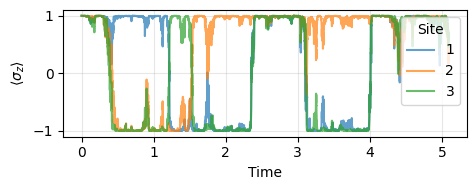

Gamma: 12.500000000000002


In [7]:
# Plot z values over time
plt.figure(figsize=(5, 2))

# Plot z_i
for i in range(3):
    plt.plot(times/(np.pi/2), z_traj[:, i], label=f'{i+1}', alpha=0.7)
plt.xlabel('Time')
plt.ylabel('$\langle \\sigma_z \\rangle$')
plt.legend(title="Site", loc="upper right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("Gamma:", sim.epsilon**2/sim.dt)


# Making Sure All Approximations hold


1. $dt \ll \tau$ for the weak measurement regime so that $\epsilon^2 \ll 1$ - we will take $10^4$
2. $\tau \ll T$ for the EP convergence regime  - we will take $10^2$
3. $dt \ll 1/\Omega$ for simulation accuracy - we will take $10^2$
4. $T \gg 1/\Omega = 1$ for coverage of the bloch sphere - we will take $10^2$
5. $N \lesssim 10^8$ while $T = Ndt$ for practical reasons.

Assuming $\Omega = J = 1$ this can be reduced to  $dt \ll \tau \ll T$ and $dt \ll 1 \ll T$
For the above ratios we can decide for each $\tau$:

$T = \max(\tau\times10^2, 10^2) $

$dt = \min(\tau\times10^{-4}, 10^{-2})$

Since the transition is expected at $\gamma = 1/\tau = 4$

In [8]:
def get_T_tau_dt_zip(gamma_list):
    tau_list = [1/gamma for gamma in gamma_list]
    T_list = [max(tau*5, 1e1) for tau in tau_list]
    dt_list = [min(tau*1e-4, 1e-3) for tau in tau_list]

    N_list = [round(T/dt) for T,dt in zip(T_list,dt_list)]
    log_10N = [round(np.log10(n)) for n in N_list]

    print(f"Gammas: {gamma_list}")
    print(f"N: {N_list}")
    print(f"log_10 N: {log_10N}")
    if np.any(np.array(N_list) >= 1e8):
        print(f"\nWARNING: N > 1e8")

    return T_list, tau_list, dt_list

# Plotting $1+\langle z^2 \rangle$ to see the convergence

In [9]:
gamma_list = np.linspace(0.1, 8, 5)
T_list, tau_list, dt_list = get_T_tau_dt_zip(gamma_list)

Gammas: [0.1   2.075 4.05  6.025 8.   ]
N: [50000, 207500, 405000, 602500, 800000]
log_10 N: [5, 5, 6, 6, 6]


gamma:0.1, N=50000
gamma:2.075, N=207500
gamma:4.05, N=404999
gamma:6.025, N=602500
gamma:8.0, N=800000


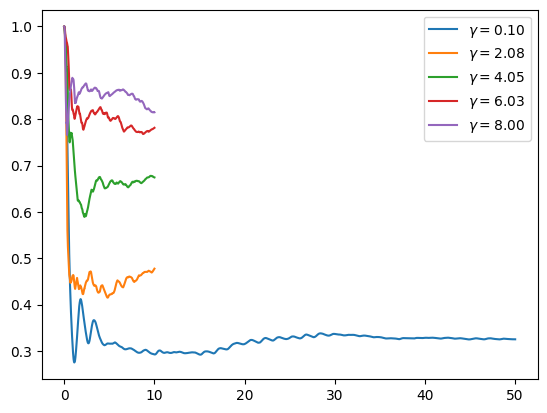

In [10]:

for tau, T, dt in zip(tau_list, T_list, dt_list):
    gamma = 1/tau
    L, omega= 5, 1
    N = int(T/dt)
    fit_portion= 0.3
    epsilon = np.sqrt(gamma*dt)
    print(f"gamma:{gamma}, N={N}")

    sim = LQubitCorrelationSimulator(
        L= L,
        J=omega,
        epsilon=epsilon,
        N_steps=N,
        T=T,
        closed_boundary=True
    )

    times = np.linspace(0, sim.T, sim.N_steps + 1)
    Q_traj, z_traj, xi_traj = sim.simulate_trajectory()

    z_sqrd_cumsum = np.cumsum((z_traj**2), axis=0)
    average_denom = np.broadcast_to(np.arange(1, z_traj.shape[0]+1), (L, z_traj.shape[0])).T
    plt.plot(times, np.average(z_sqrd_cumsum/average_denom, axis=1), label=f"$\\gamma={gamma:.2f}$")

plt.legend()
plt.show()

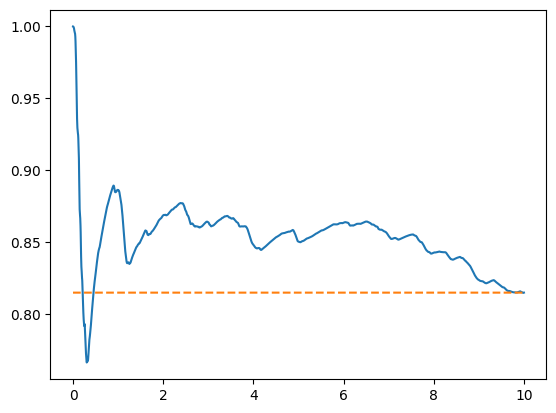

In [11]:
z_sqrd_cumsum = np.cumsum((z_traj**2), axis=0)
average_denom = np.broadcast_to(np.arange(1, z_traj.shape[0]+1), (L, z_traj.shape[0])).T
plt.plot(times, np.average(z_sqrd_cumsum/average_denom, axis=1))
a = np.average(z_traj**2)
plt.plot(times, [a for t in times], "--", label=f"$\\gamma={gamma:.2f}$")

# The main part - plotting $1+\langle z^2 \rangle$ vs $\log \gamma / 4$ for different L

In [38]:
gamma_list = np.logspace(-2,3,40)

tau_list = [1/gamma for gamma in gamma_list]
T_list = [max(tau*20, 1e1) for tau in tau_list]
dt_list = [min(tau*1e-3, 1e-4) for tau in tau_list]

N_list = [round(T/dt) for T,dt in zip(T_list,dt_list)]
log_10N = [round(np.log10(n)) for n in N_list]
print(gamma_list)
print(N_list)
print(T_list)
log_10N

[1.00000000e-02 1.34339933e-02 1.80472177e-02 2.42446202e-02
 3.25702066e-02 4.37547938e-02 5.87801607e-02 7.89652287e-02
 1.06081836e-01 1.42510267e-01 1.91448198e-01 2.57191381e-01
 3.45510729e-01 4.64158883e-01 6.23550734e-01 8.37677640e-01
 1.12533558e+00 1.51177507e+00 2.03091762e+00 2.72833338e+00
 3.66524124e+00 4.92388263e+00 6.61474064e+00 8.88623816e+00
 1.19377664e+01 1.60371874e+01 2.15443469e+01 2.89426612e+01
 3.88815518e+01 5.22334507e+01 7.01703829e+01 9.42668455e+01
 1.26638017e+02 1.70125428e+02 2.28546386e+02 3.07029063e+02
 4.12462638e+02 5.54102033e+02 7.44380301e+02 1.00000000e+03]
[20000000, 14887606, 11082041, 8249253, 6140581, 4570928, 3402509, 2532760, 1885337, 1403408, 1044669, 777631, 578853, 430887, 320744, 238755, 177725, 132295, 100000, 100000, 100000, 100000, 100000, 100000, 119378, 160372, 215443, 289427, 388816, 522335, 701704, 942668, 1266380, 1701254, 2285464, 3070291, 4124626, 5541020, 7443803, 10000000]
[np.float64(2000.0), np.float64(1488.76060265

[7,
 7,
 7,
 7,
 7,
 7,
 7,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 7,
 7,
 7,
 7]

In [149]:
from datetime import datetime

L_list = np.array([3,4,5])
average_z_sqrd = np.zeros((len(gamma_list), len(L_list)))

for iL, L in enumerate(L_list):
    for igamma, (tau, T, dt) in enumerate(zip(tau_list, T_list, dt_list)):
        time = datetime.now()
        gamma = 1/tau
        omega = 1
        N = int(T/dt)
        fit_portion= 0.3
        epsilon = np.sqrt(gamma*dt)
        print(f"L:{L}, gamma:{gamma}, N={N}")


        sim = LQubitCorrelationSimulator(
            L= L,
            J=omega,
            epsilon=epsilon,
            N_steps=N,
            T=T,
            closed_boundary=True
        )

        times = np.linspace(0, sim.T, sim.N_steps + 1)
        Q_traj, z_traj, xi_traj = sim.simulate_trajectory()

        last_average_z_sqrd = np.average(z_traj**2)
        average_z_sqrd[igamma, iL] = last_average_z_sqrd
        time_took = (datetime.now() - time).total_seconds()
        print(f"z^2: {last_average_z_sqrd}, time took: {time_took//60:.0f}:{time_took%60:.2f}")


L:7, gamma:0.01, N=20000000
z^2: 0.28127271858490527, time took: 21:4.81
L:7, gamma:0.013433993325989001, N=14887606
z^2: 0.2760415907383765, time took: 16:13.62
L:7, gamma:0.018047217668271703, N=11082040
z^2: 0.2771446653545494, time took: 12:16.75
L:7, gamma:0.024244620170823284, N=8249252
z^2: 0.2831616327472216, time took: 9:1.58
L:7, gamma:0.03257020655659783, N=6140581
z^2: 0.2869358273333308, time took: 6:40.84
L:7, gamma:0.043754793750741844, N=4570927
G has nan
(4.804040858372059e+239-1.1834395814056525e+239j)
[[ 1.46670698e+236+7.87086644e+235j -1.97997968e+239+3.77801382e+239j
  -1.43207108e+239-7.22904918e+237j -1.37753160e+239-4.23542024e+239j
  -4.18395306e+239+2.12080981e+239j -2.15333443e+239-9.47372243e+238j
   2.51659713e+239-4.36692001e+239j -5.62331540e+239+5.67581295e+238j
   3.22404142e+238-2.58745940e+239j -3.94683101e+239-1.81410604e+237j
   4.80404086e+239-1.18343958e+239j  2.13820105e+239-2.07183998e+239j
  -2.94898171e+238+2.29464015e+239j  2.39346904e+238+4

Text(0.5, 1.0, '$z^2$ vs $\\gamma$')

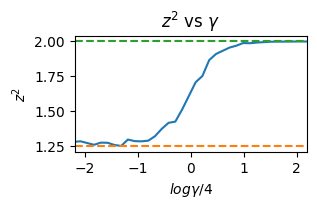

In [185]:
plt.figure(figsize=(3,1.5))
mask = average_z_sqrd[:,0] > 0.25
log_g = np.log10(gamma_list[mask]/4)
avg_z_sqrd = average_z_sqrd[:,0][mask]
deriv = np.diff(avg_z_sqrd)/np.diff(log_g)

plt.plot(log_g, 1+avg_z_sqrd, label=f"$L={L_list[0]}$")

plt.plot(log_g, [1.25 for gamma in log_g], "--", label="1.25")
plt.plot(log_g, [2 for gamma in log_g], "--", label="2")

plt.xlabel("$log\\gamma/4$")
plt.ylabel("$1+z^2$")
plt.xlim(-2.2, 2.2)
plt.title(f"$z^2$ vs $\\gamma$")
